<h1>Program 3: Clustering</h1>

<h3>Understanding Data</h3>

<h5>Data Visualization</h5>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Load the data
file_path = "train.dat"
data_df = pd.read_csv(file_path,header=None)

In [32]:
# Basic Info
print(data_df.shape)

(11500, 178)


In [6]:
# Summary statistics
print(data_df.describe())

                0             1             2             3             4    \
count  11500.000000  11500.000000  11500.000000  11500.000000  11500.000000   
mean     -11.581391    -10.911565    -10.187130     -9.143043     -8.009739   
std      165.626284    166.059609    163.524317    161.269041    160.998007   
min    -1839.000000  -1838.000000  -1835.000000  -1845.000000  -1791.000000   
25%      -54.000000    -55.000000    -54.000000    -54.000000    -54.000000   
50%       -8.000000     -8.000000     -7.000000     -8.000000     -8.000000   
75%       34.000000     35.000000     36.000000     36.000000     35.000000   
max     1726.000000   1713.000000   1697.000000   1612.000000   1518.000000   

                5             6            7            8             9    \
count  11500.000000  11500.000000  11500.00000  11500.00000  11500.000000   
mean      -7.003478     -6.502087     -6.68713     -6.55800     -6.168435   
std      161.328725    161.467837    162.11912    162.033

In [33]:
# Check for missing values
missing_values = data_df.isnull().sum().sum()
print(f"Missing values: {missing_values}")

Missing values: 0


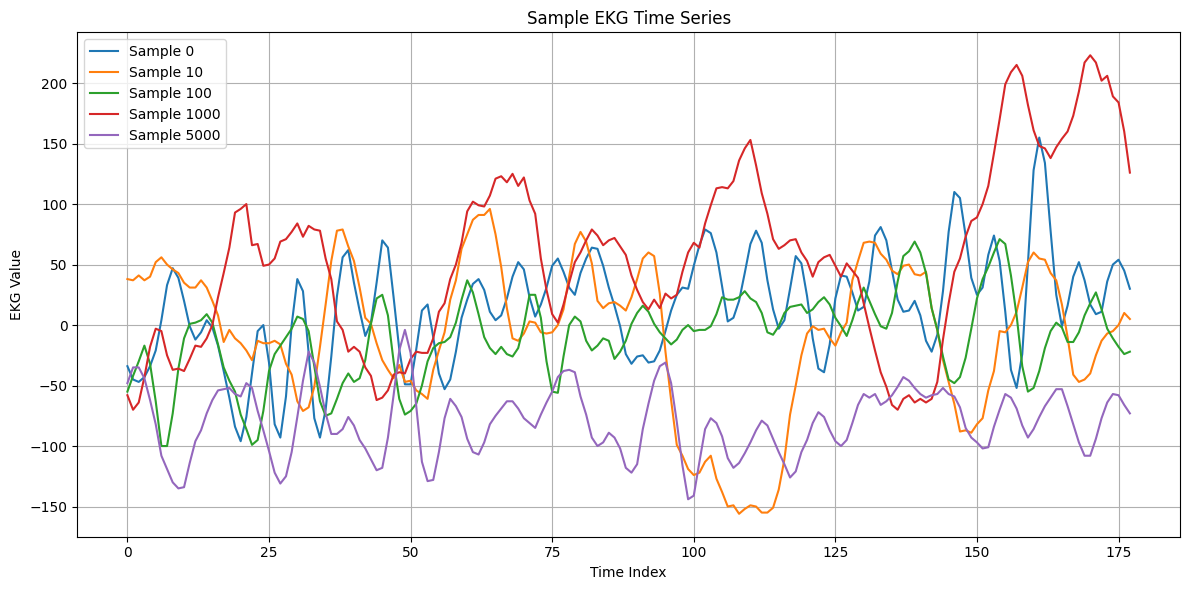

In [34]:
# Visualize a few EKG sample signals
sample_indices = [0,10,100,1000,5000]
sample_plots = data_df.iloc[sample_indices].T

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    plt.plot(sample_plots.index, sample_plots[idx], label=f'Sample {idx}')
plt.xlabel('Time Index')
plt.ylabel('EKG Value')
plt.title('Sample EKG Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

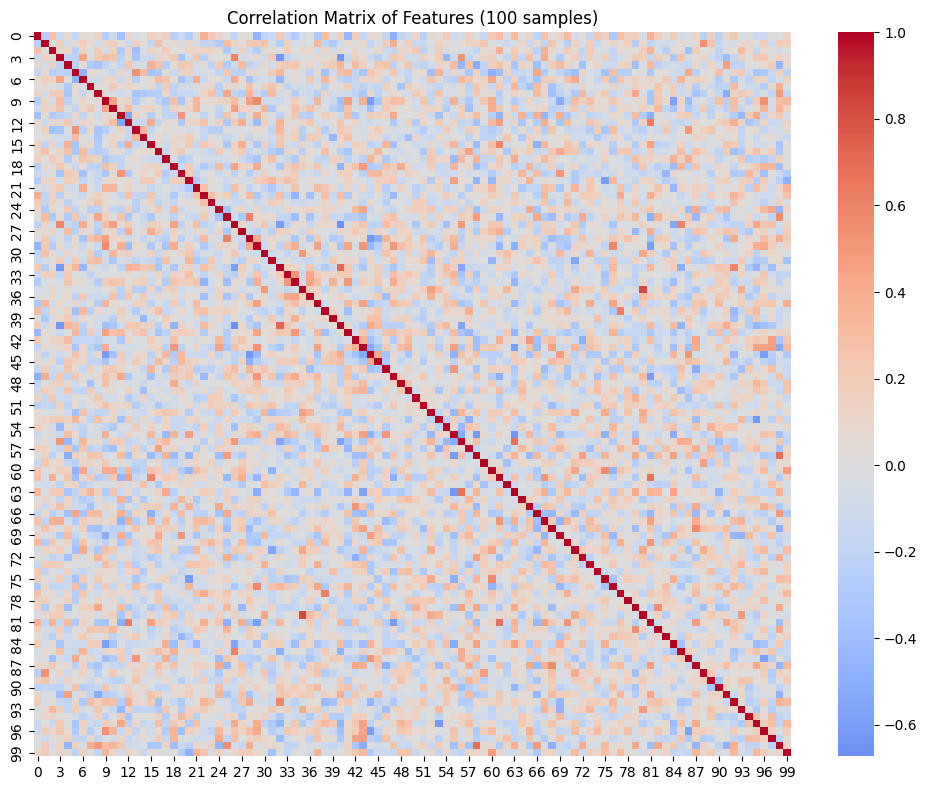

In [35]:
# Correlation heatmap across 1000 samples to understand redundancy
corr_matrix = data_df.iloc[:100].T.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features (100 samples)')
plt.tight_layout()
plt.show()

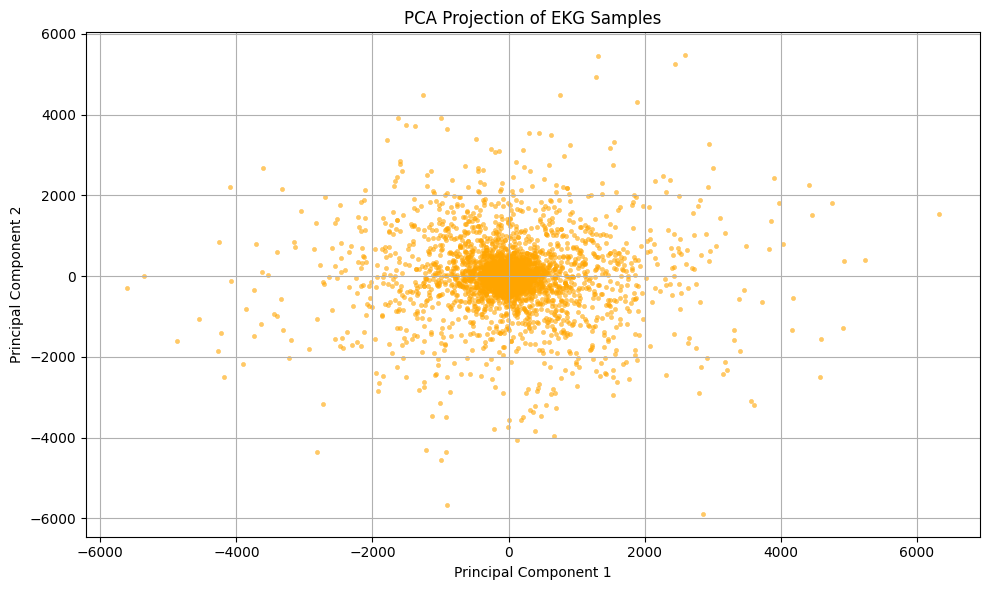

In [36]:
from sklearn.decomposition import PCA

# PCA: reduce dimensionality to 2 components
pca = PCA(n_components=2)
X_2d = pca.fit_transform(data_df)

# Plot the data projected to 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], s=10, alpha=0.6, edgecolor=None, color="orange")
plt.title('PCA Projection of EKG Samples')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

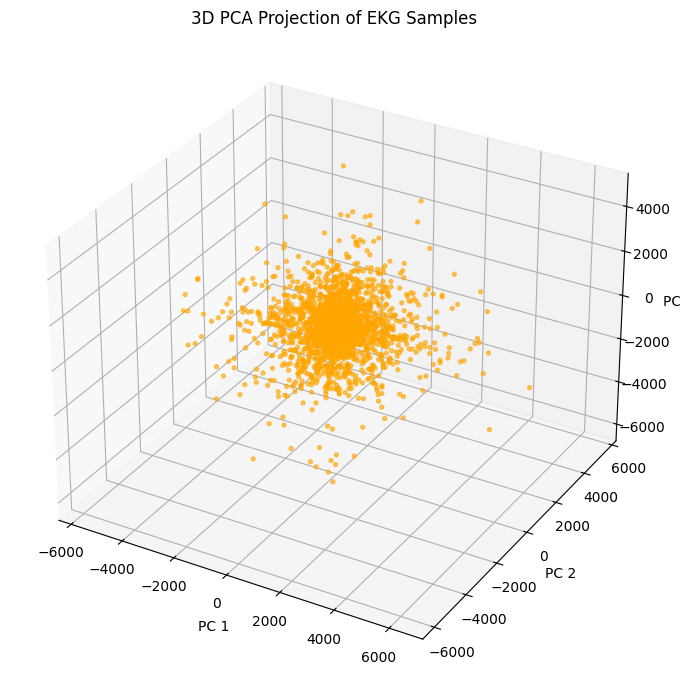

In [37]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(data_df)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c='orange', s=8, alpha=0.6)
ax.set_title("3D PCA Projection of EKG Samples")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.tight_layout()
plt.show()

<h3>Clustering Algorithm</h3>

<h5>0. Data preprocessing</h5>

In [38]:
from sklearn.preprocessing import StandardScaler
from scipy.fft import fft

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_df)

pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled)

X_fft = np.abs(fft(data_df.values))
#X_fft = fft(data_df.values)
X_fft_scaled = scaler.fit_transform(X_fft)
X_fft_pca = pca.fit_transform(X_fft)
X_fft_filter = X_fft[:, :25]

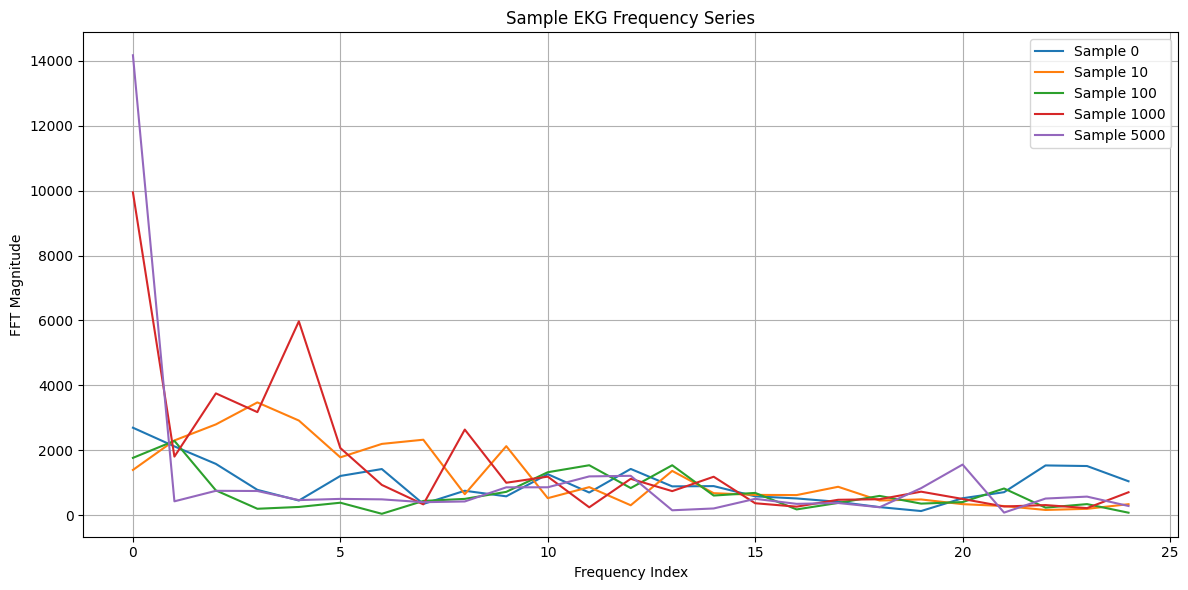

In [39]:

# Select sample indices
sample_indices = [0, 10, 100, 1000, 5000]

# Extract and transpose the FFT-filtered samples
sample_plots = X_fft_filter[sample_indices].T  # shape: [freq_bins, num_samples]

# Plot
plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    plt.plot(sample_plots[:, i], label=f'Sample {idx}')

plt.xlabel('Frequency Index')
plt.ylabel('FFT Magnitude')
plt.title('Sample EKG Frequency Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h5>1. K-means Algorithm</h5>

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
k = 115
kmeans = KMeans(n_clusters=k, random_state = 42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

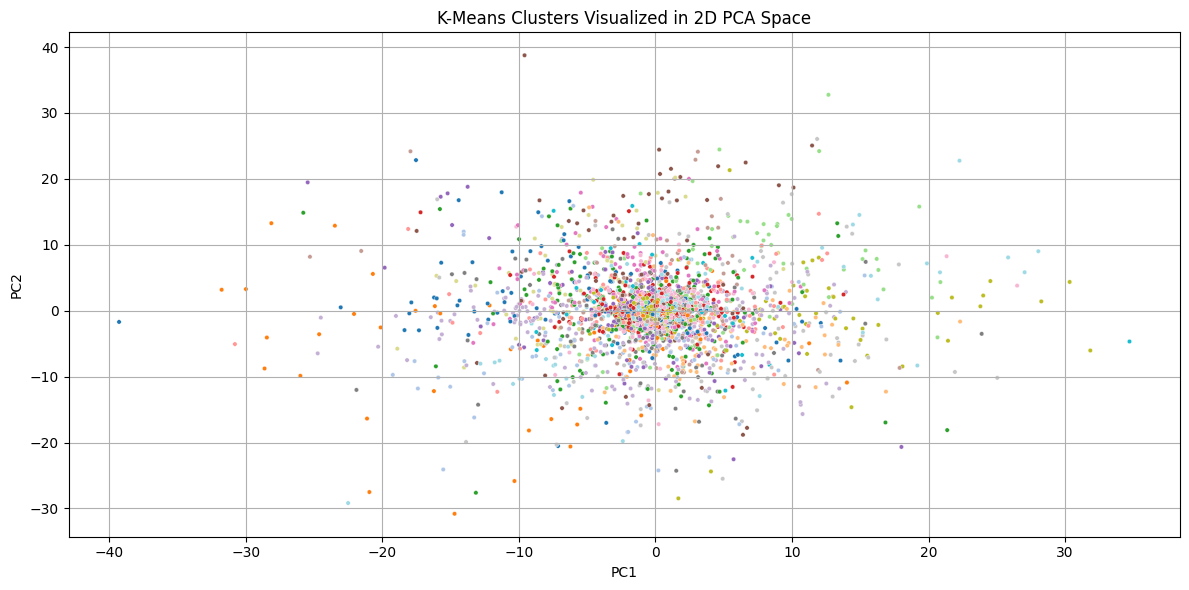

In [15]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=cluster_labels, palette='tab20', s=10, legend=None)
plt.title('K-Means Clusters Visualized in 2D PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Evaluation metrics
sil_score = silhouette_score(X_pca, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: -0.00011581434890387908


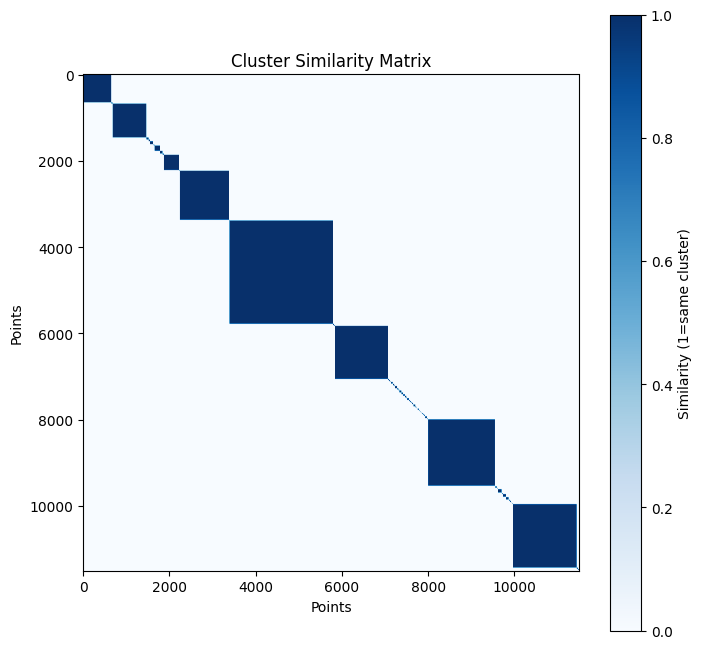

In [18]:
def plot_similarity_matrix(labels, title="Cluster Similarity Matrix"):
    n = len(labels)
    sim_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            # mark as similar if same cluster and not noise
            if labels[i] != -1 and labels[i] == labels[j]:
                sim_matrix[i, j] = 1

    # Reorder by cluster label for a blocky matrix
    sorted_idx = np.argsort(labels)
    sim_matrix = sim_matrix[sorted_idx][:, sorted_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(sim_matrix, cmap='Blues')
    plt.title(title)
    plt.xlabel("Points")
    plt.ylabel("Points")
    plt.colorbar(label="Similarity (1=same cluster)")
    plt.show()

plot_similarity_matrix(cluster_labels)

In [13]:
with open("k_mean.txt","w") as f:
    for label in cluster_labels:
        f.write(f"{label + 1}\n")

<h5>2. Multiple Gaussians Model</h5>

In [14]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

In [58]:
n_components = 115
gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
gmm_labels = gmm.fit_predict(X_rich)

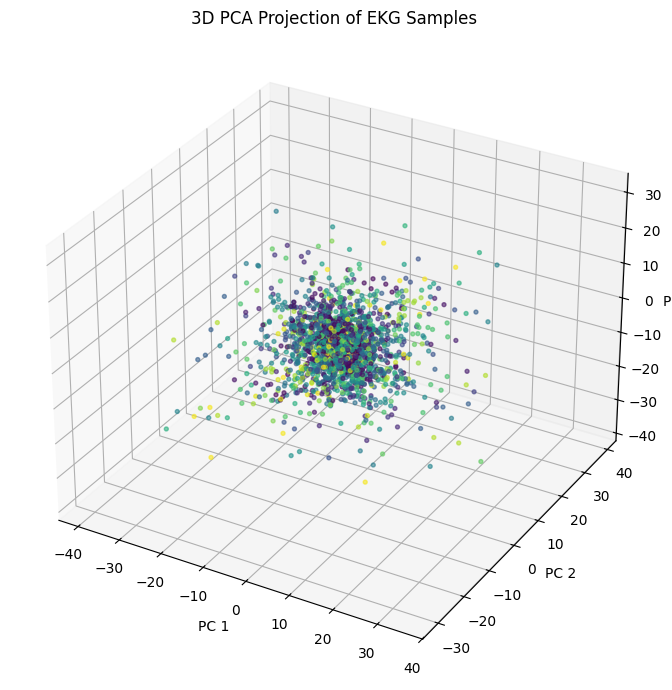

In [59]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=gmm_labels, s=8, alpha=0.6)
ax.set_title("3D PCA Projection of EKG Samples")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.tight_layout()
plt.show()

In [60]:
sil = silhouette_score(X_rich, gmm_labels)
print("Silhouette Score:", sil)

Silhouette Score: -0.05095095326159338


<!-- <h6>Summarizing Silhouette Score</h6>
<p><b>Filter 25 elements:</b> -0.047</p>
<p><b>Filter 35 elements:</b> -0.0614</p>
<p><b>Filter 40 elements:</b> -0.071</p> -->

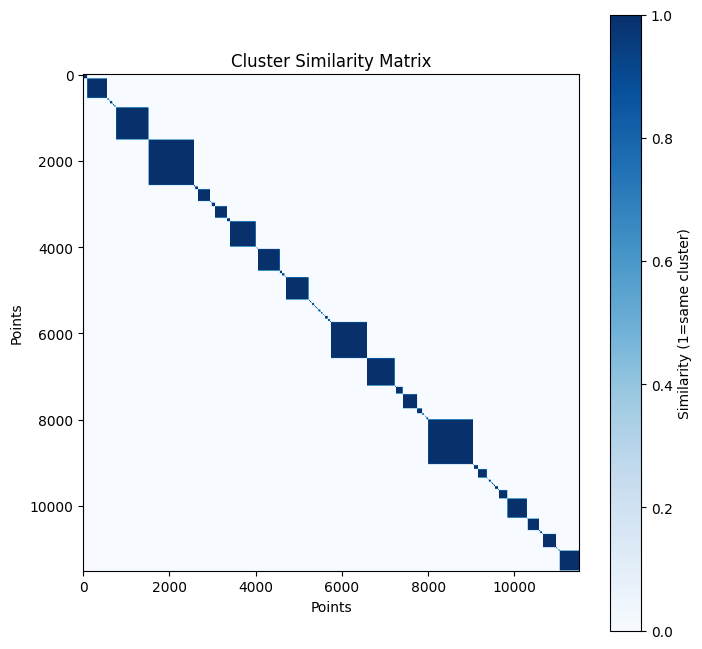

In [17]:
def plot_similarity_matrix(labels, title="Cluster Similarity Matrix"):
    n = len(labels)
    sim_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            # mark as similar if same cluster and not noise
            if labels[i] != -1 and labels[i] == labels[j]:
                sim_matrix[i, j] = 1

    # Reorder by cluster label for a blocky matrix
    sorted_idx = np.argsort(labels)
    sim_matrix = sim_matrix[sorted_idx][:, sorted_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(sim_matrix, cmap='Blues')
    plt.title(title)
    plt.xlabel("Points")
    plt.ylabel("Points")
    plt.colorbar(label="Similarity (1=same cluster)")
    plt.show()

plot_similarity_matrix(gmm_labels)

In [61]:
with open("GMM.txt","w") as f:
    for label in gmm_labels:
        f.write(f"{label + 1}\n")

In [20]:
print(len(np.unique(gmm_labels)))

115


<h5>3. Agglomerative Clustering</h5>

In [17]:
from sklearn.cluster import AgglomerativeClustering

In [18]:
agg = AgglomerativeClustering(n_clusters=115, linkage='ward')
agg_labels = agg.fit_predict(X_pca)

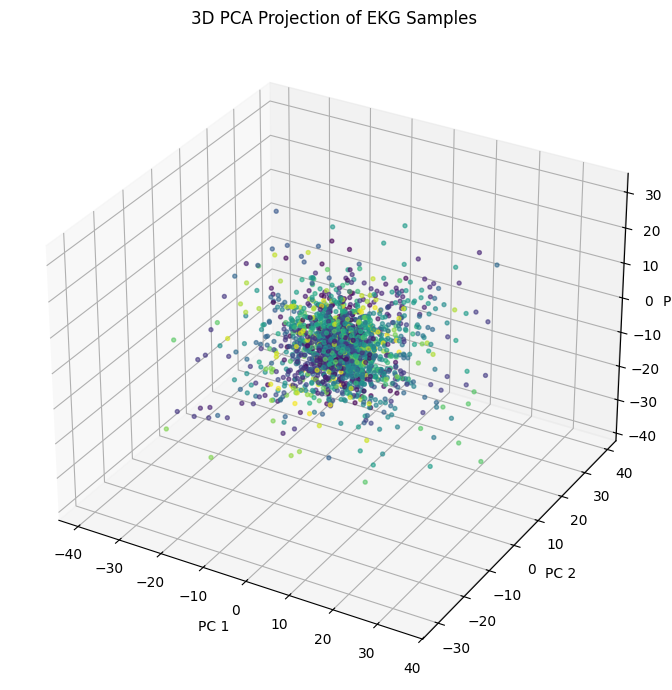

In [19]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=agg_labels, s=8, alpha=0.6)
ax.set_title("3D PCA Projection of EKG Samples")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.tight_layout()
plt.show()

In [20]:
sil = silhouette_score(X_fft_filter, agg_labels)
print("Silhouette Score:", sil)

Silhouette Score: 0.018416887463109707


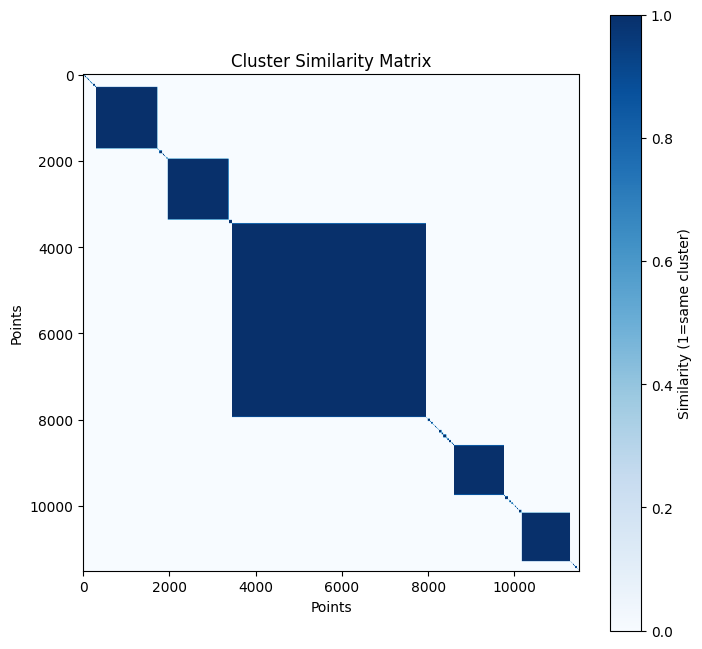

In [21]:
def plot_similarity_matrix(labels, title="Cluster Similarity Matrix"):
    n = len(labels)
    sim_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            # mark as similar if same cluster and not noise
            if labels[i] != -1 and labels[i] == labels[j]:
                sim_matrix[i, j] = 1

    # Reorder by cluster label for a blocky matrix
    sorted_idx = np.argsort(labels)
    sim_matrix = sim_matrix[sorted_idx][:, sorted_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(sim_matrix, cmap='Blues')
    plt.title(title)
    plt.xlabel("Points")
    plt.ylabel("Points")
    plt.colorbar(label="Similarity (1=same cluster)")
    plt.show()

plot_similarity_matrix(agg_labels)

In [98]:
with open("agg.txt","w") as f:
    for label in agg_labels:
        f.write(f"{label + 1}\n")

In [88]:
print(len(np.unique(agg_labels)))

115


<h5>4. DBSCAN</h5>

In [87]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [91]:
# Step 1: Run DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)  # Use PCA-reduced data

# Step 2: Reassign noise points to nearest valid cluster
noise_indices = np.where(dbscan_labels == -1)[0]
non_noise_indices = np.where(dbscan_labels != -1)[0]

if len(noise_indices) > 0 and len(non_noise_indices) > 0:
    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(X_pca[non_noise_indices])
    _, neighbors = knn.kneighbors(X_pca[noise_indices])
    nearest_labels = dbscan_labels[non_noise_indices][neighbors.flatten()]
    dbscan_labels[noise_indices] = nearest_labels

# Step 3: Count existing clusters
true_labels = set(dbscan_labels)
if -1 in true_labels:
    true_labels.remove(-1)
current_k = len(true_labels)

# Step 4: Split largest cluster to make total exactly 115
if current_k < 115:
    counts = Counter(dbscan_labels)
    largest_cluster = max(counts, key=counts.get)
    largest_indices = np.where(dbscan_labels == largest_cluster)[0]

    n_to_add = 115 - current_k + 1  # +1 to fix overwrite issue

    # Temporarily remove largest cluster label
    dbscan_labels = np.where(dbscan_labels == largest_cluster, -999, dbscan_labels)

    # KMeans to split that cluster
    kmeans = KMeans(n_clusters=n_to_add, random_state=42)
    sub_labels = kmeans.fit_predict(X_pca[largest_indices])

    # Offset to ensure label uniqueness
    max_label = dbscan_labels.max()
    sub_labels += max_label + 1

    # Assign sub-cluster labels
    dbscan_labels[largest_indices] = sub_labels

# Step 5: Normalize to 0–114 range
dbscan_labels = LabelEncoder().fit_transform(dbscan_labels)

# Final check
print("Final cluster count:", len(np.unique(dbscan_labels)))

Final cluster count: 115


In [92]:
sil = silhouette_score(X_fft_filter, dbscan_labels)
print("Silhouette Score:", sil)

Silhouette Score: -0.13576929998382112


In [ ]:
with open("dbscan.txt","w") as f:
    for label in dbscan_labels:
        f.write(f"{label + 1}\n")